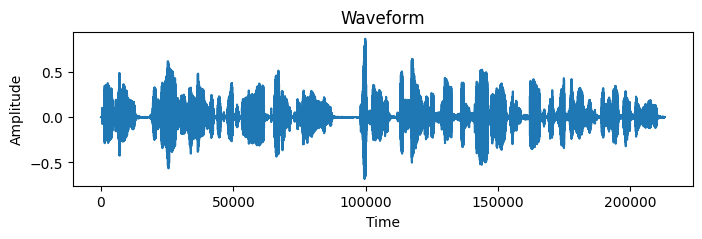

In [1]:
# import
import torchaudio
import matplotlib.pyplot as plt
from configs import Configs as cfg

#load wav
wav_path = f"{cfg.wav_path}/LJ001-0001.wav"
waveform, sample_rate = torchaudio.load(wav_path, normalize=True)

#plot wav
_ = plt.figure(figsize=(8,2))
_ = plt.title("Waveform")
_ = plt.plot(waveform.squeeze(0).detach().cpu().numpy())
_ = plt.xlabel("Time")
_ = plt.ylabel("Amplitude")

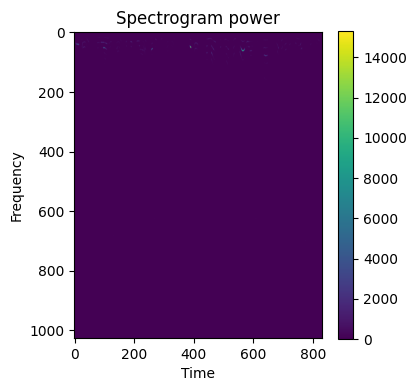

In [2]:
from utils.melspecs import spec_transform

# wav -> spectrogram-power
spec = spec_transform(waveform)

# Plot spectrogram-power
fig, (ax1) = plt.subplots(figsize=(4, 4), ncols=1)

_ = ax1.set_title("Spectrogram power")
pos = ax1.imshow(spec.squeeze(0).detach().cpu().numpy())
_ = fig.colorbar(pos, ax=ax1)

_ = ax1.set_xlabel("Time")
_ = ax1.set_ylabel("Frequency")

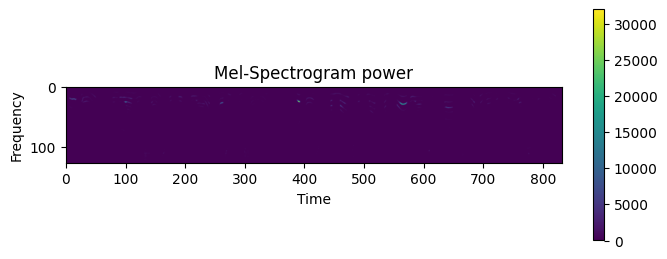

In [3]:
from utils.melspecs import mel_scale_transform

# spectrogram-power to mel-spectgrogram-power
mel_spec = mel_scale_transform(spec)

# Plot mel-spectgrogram-power
fig, (ax1) = plt.subplots(figsize=(8, 3), ncols=1)

_ = ax1.set_title("Mel-Spectrogram power")
pos = ax1.imshow(mel_spec.squeeze(0).detach().cpu().numpy())
_ = fig.colorbar(pos, ax=ax1)

_ = ax1.set_xlabel("Time")
_ = ax1.set_ylabel("Frequency")

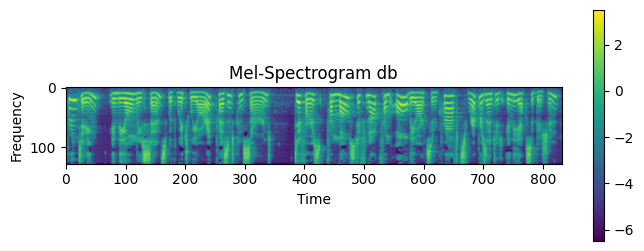

In [4]:
from utils.melspecs import pow_to_db_mel_spec

# mel-spectrogram-power to mel-spectrogram-db
db_mel_spec = pow_to_db_mel_spec(mel_spec)

# Plot mel-spectrogram-db
fig, (ax1) = plt.subplots(figsize=(8, 3), ncols=1)

_ = ax1.set_title("Mel-Spectrogram db")
pos = ax1.imshow(db_mel_spec.squeeze(0).detach().cpu().numpy())
_ = fig.colorbar(pos, ax=ax1)

_ = ax1.set_xlabel("Time")
_ = ax1.set_ylabel("Frequency")

In [5]:
import IPython.display
from utils.melspecs import inverse_mel_spec_to_wav

# mel-spec-db -> waveform
pseudo_wav = inverse_mel_spec_to_wav(db_mel_spec.cuda())
# dISPLAY ORIGINAL AND PSEUDO WAVE
IPython.display.Audio(waveform, rate=cfg.sr)



In [6]:
IPython.display.Audio(
    pseudo_wav.detach().cpu().numpy(),
    rate=cfg.sr
)

In [7]:
from data import TextMelDataset, text_mel_collate_fn
import pandas as pd
import torch
df = pd.read_csv(cfg.csv_path)
dataset = TextMelDataset(
            df=df,
            wav_path=cfg.wav_path,
            sample_rate=cfg.sr
        )

train_loader = torch.utils.data.DataLoader(
    dataset, 
    num_workers=2, 
    shuffle=True,
    sampler=None, 
    batch_size=cfg.batch_size,
    pin_memory=True, 
    drop_last=True, 
    collate_fn=text_mel_collate_fn
)

def names_shape(names, shape):  
  assert len(names) == len(shape)
  return "(" + ", ".join([f"{k}={v}" for k, v in list(zip(names, shape))]) + ")"

for i, batch in enumerate(train_loader):
  text_padded, \
  text_lengths, \
  mel_padded, \
  mel_lengths, \
  stop_token_padded = batch

  print(f"=========batch {i}=========")
  print("text_padded:", names_shape(["N", "S"], text_padded.shape))
  print("text_lengths:", names_shape(["N"], text_lengths.shape))
  print("mel_padded:", names_shape(["N", "TIME", "FREQ"], mel_padded.shape))
  print("mel_lengths:", names_shape(["N"], mel_lengths.shape))
  print("stop_token_padded:", names_shape(["N", "TIME"], stop_token_padded.shape))

  if i > 0:
    break

=========batch 0=========
text_padded: (N=32, S=157)
text_lengths: (N=32)
mel_padded: (N=32, TIME=858, FREQ=128)
mel_lengths: (N=32)
stop_token_padded: (N=32, TIME=858)
=========batch 1=========
text_padded: (N=32, S=169)
text_lengths: (N=32)
mel_padded: (N=32, TIME=864, FREQ=128)
mel_lengths: (N=32)
stop_token_padded: (N=32, TIME=864)
